In [127]:
import os
import cv2
import shutil
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [128]:
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Conv2DTranspose, Add, concatenate, average, Dropout
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [129]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from albumentations import Compose, OneOf, Flip, Rotate, RandomContrast, RandomGamma, RandomBrightness, ElasticTransform, GridDistortion, OpticalDistortion, RGBShift, CLAHE

In [130]:
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from skimage.transform import resize
from sklearn.metrics import classification_report

## Loading the dataset

### Input Pipeline
* The data is loaded with its respective masks
* The data is then shuffled 
* Splited & Divided into train,test and validation sets 








In [131]:
train_image_dir = r'/kaggle/input/concrete-crack-dataset/Conglomerate Concrete Crack Detection/Train/images'
train_mask_dir = r'/kaggle/input/concrete-crack-dataset/Conglomerate Concrete Crack Detection/Train/masks'

test_image_dir = r'/kaggle/input/concrete-crack-dataset/Conglomerate Concrete Crack Detection/Test/images'
test_mask_dir = r'/kaggle/input/concrete-crack-dataset/Conglomerate Concrete Crack Detection/Test/masks'

In [132]:
train_image_paths = sorted([os.path.join(train_image_dir, fname) for fname in os.listdir(train_image_dir) if fname.endswith(".jpg") and not fname.startswith(".")])
train_mask_paths = sorted([os.path.join(train_mask_dir, fname) for fname in os.listdir(train_mask_dir) if fname.endswith(".jpg") and not fname.startswith(".")])

test_image_paths = sorted([os.path.join(test_image_dir, fname) for fname in os.listdir(test_image_dir) if fname.endswith(".jpg") and not fname.startswith(".")])
test_mask_paths = sorted([os.path.join(test_mask_dir, fname) for fname in os.listdir(test_mask_dir) if fname.endswith(".jpg") and not fname.startswith(".")])

print("Number of training images : ", len(train_image_paths))
print("Number of training masks : ", len(train_mask_paths))
print('\n')
print("Number of testing images : ", len(test_image_paths))
print("Number of testing masks : ", len(test_mask_paths))



Number of training images :  2037
Number of training masks :  2037


Number of testing images :  303
Number of testing masks :  303


In [133]:
# Shuffle
import random
combined = list(zip(train_image_paths, train_mask_paths))
random.shuffle(combined)

train_image_paths[:], train_mask_paths[:] = zip(*combined)

In [134]:
# Splitting
train_image_files = train_image_paths[:270]
train_mask_files = train_mask_paths[:270]

valid_image_files = train_image_paths[270:]
valid_mask_files = train_mask_paths[270:]

print(len(train_image_files), len(train_mask_files))
print(len(valid_image_files), len(valid_mask_files))


270 270
1767 1767


## Generator creation 
* A custom generator is created which combines the  image with its repective masks.
* All data is augmented using albumentation library. 
* Random flips and rotations along with more attributes of the albumentation library are used to augment the images present in the training data

In [135]:
batch_size = 10
img_dim=(448, 448)

In [136]:


class Generator(Sequence):

    def __init__(self, x_set, y_set, batch_size=5, img_dim=(128, 128), augment=False, gamma=2.5):
        self.x = x_set
        self.y = y_set
        self.batch_size = batch_size
        self.img_dim = img_dim
        self.augment = augment
        self.gamma = gamma
        
        # Define power law transformation table
        self.inv_gamma = 1.0 / self.gamma
        self.table = np.array([((i / 255.0) ** self.inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

        # Define augmentation
        self.augmentations = Compose(
            [
                Flip(p=0.7),
                Rotate(p=0.7),
                OneOf([
                    RandomContrast(),
                    RandomGamma(),
                    RandomBrightness()
                ], p=0.3),
                OneOf([
                    ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
                    GridDistortion(),
                    OpticalDistortion(distort_limit=2, shift_limit=0.5)
                ], p=0.3),
            ])

    def powerlaw(self, image):
        return cv2.LUT(image, self.table)

    def __len__(self):
        return math.ceil(len(self.x) / self.batch_size)

    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_x = np.array([cv2.resize(cv2.cvtColor(cv2.imread(file_name, -1), cv2.COLOR_BGR2RGB), (self.img_dim[1], self.img_dim[0])) for file_name in batch_x])
        batch_y = np.array([(cv2.resize(cv2.imread(file_name, cv2.IMREAD_GRAYSCALE), (self.img_dim[1], self.img_dim[0])) > 0).astype(np.uint8) for file_name in batch_y])

        if self.augment:
            aug = [self.augmentations(image=i, mask=j) for i, j in zip(batch_x, batch_y)]
            batch_x = np.array([i['image'] for i in aug])
            batch_y = np.array([j['mask'] for j in aug])

        # Apply power law transformation
        batch_x = np.array([self.powerlaw(image) for image in batch_x])

        batch_y = np.expand_dims(batch_y, -1)

        return batch_x / 255, batch_y / 1


In [137]:
train_generator = Generator(train_image_files, train_mask_files)
validation_generator = Generator(valid_image_files, valid_mask_files)
test_generator=Generator(test_image_paths,test_mask_paths)

/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1284: FutureWarning: RandomContrast has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1258: FutureWarning: This class has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(


In [138]:
for i, j in train_generator:
  break

print(i.shape)
print(j.shape)

(5, 128, 128, 3)
(5, 128, 128, 1)


In [139]:
for i, j in validation_generator:
  break

print(i.shape)
print(j.shape)

(5, 128, 128, 3)
(5, 128, 128, 1)


In [140]:
for i,j in test_generator:
  break
print(i.shape)
print(j.shape)

(5, 128, 128, 3)
(5, 128, 128, 1)


### Plotting of the unaugmented images along with known images

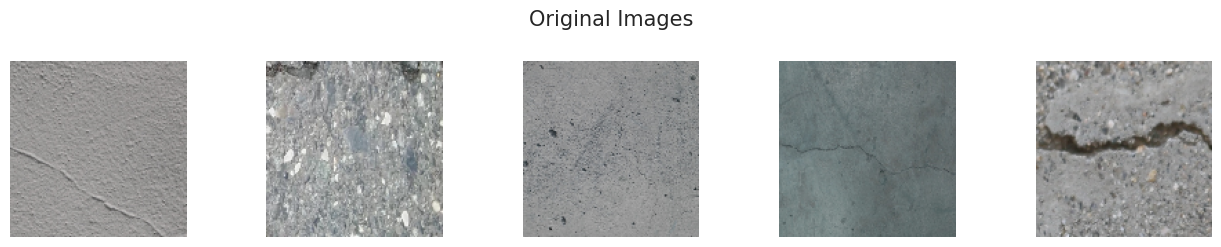

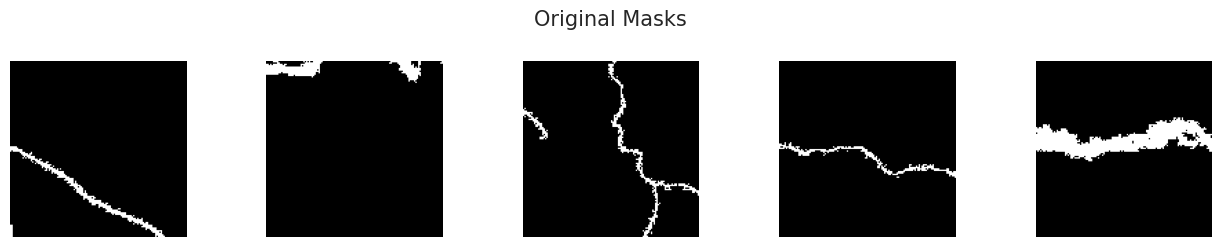

In [141]:
# Train generator samples (Un-augmented)
for i, j in train_generator:
    break

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Images', fontsize=15)
axes = axes.flatten()
for img, ax in zip(i[:5], axes[:5]):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Masks', fontsize=15)
axes = axes.flatten()
for img, ax in zip(j[:5], axes[:5]):
    ax.imshow(np.squeeze(img, -1), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

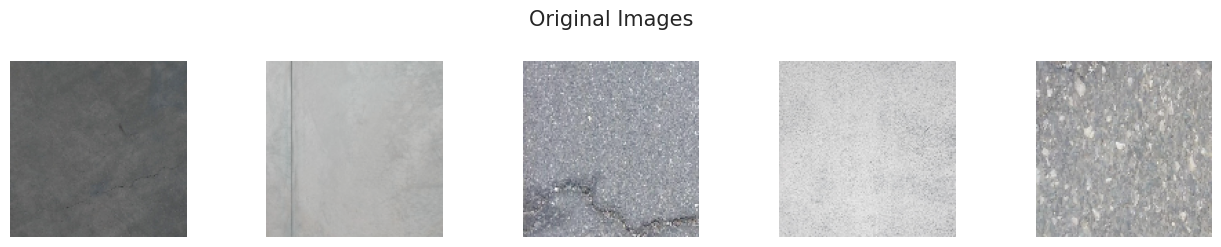

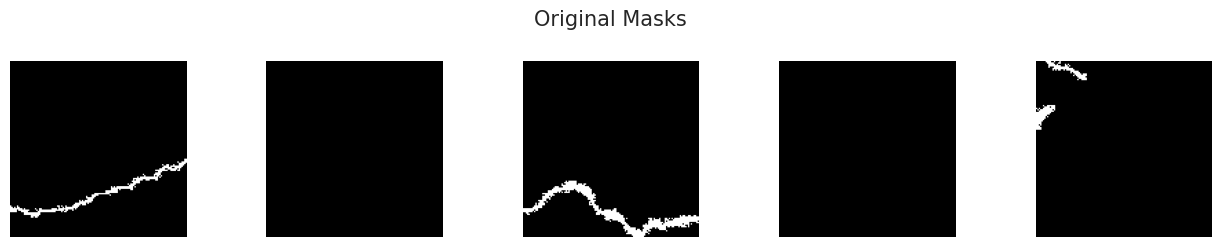

In [142]:
# Validation generator samples (Un-augmented)
for i, j in validation_generator:
    break

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Images', fontsize=15)
axes = axes.flatten()
for img, ax in zip(i[:5], axes[:5]):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Masks', fontsize=15)
axes = axes.flatten()
for img, ax in zip(j[:5], axes[:5]):
    ax.imshow(np.squeeze(img, -1), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

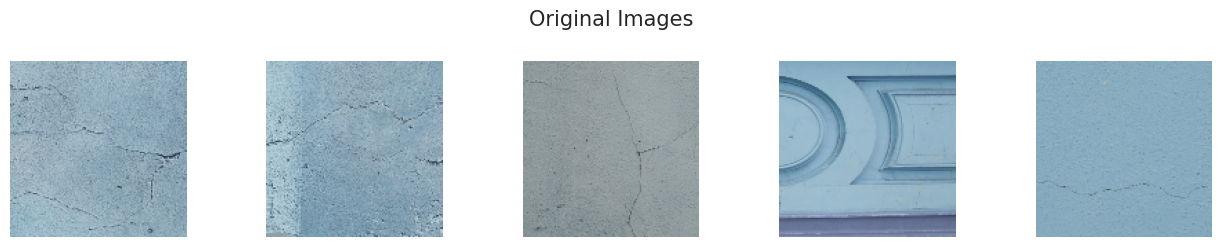

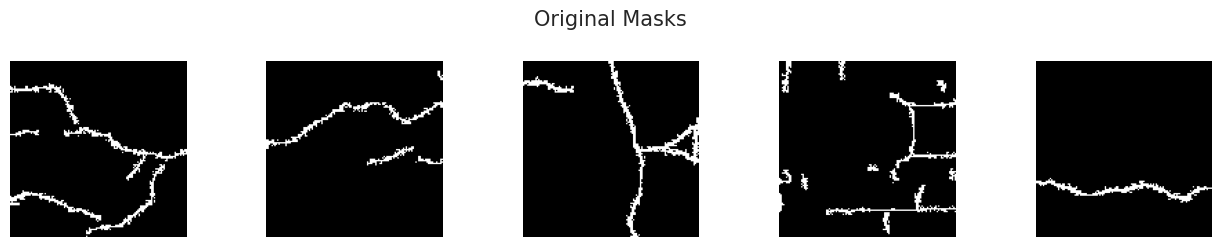

In [143]:
# test generator samples (Un-augmented)
for i, j in test_generator:
    break

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Images', fontsize=15)
axes = axes.flatten()
for img, ax in zip(i[:5], axes[:5]):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Original Masks', fontsize=15)
axes = axes.flatten()
for img, ax in zip(j[:5], axes[:5]):
    ax.imshow(np.squeeze(img, -1), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [144]:
tg = Generator(train_image_files, train_mask_files, batch_size, img_dim, augment = True)
vg = Generator(valid_image_files, valid_mask_files, batch_size, img_dim, augment = False)
testg=Generator(test_image_paths,test_mask_paths,batch_size,img_dim,augment=False)

In [145]:
for i, j in tg:
  break

print(i.shape)
print(j.shape)

(10, 448, 448, 3)
(10, 448, 448, 1)


In [146]:
for i, j in vg:
  break

print(i.shape)
print(j.shape)

(10, 448, 448, 3)
(10, 448, 448, 1)


In [147]:
for i, j in testg:
  break

print(i.shape)
print(j.shape)

(10, 448, 448, 3)
(10, 448, 448, 1)


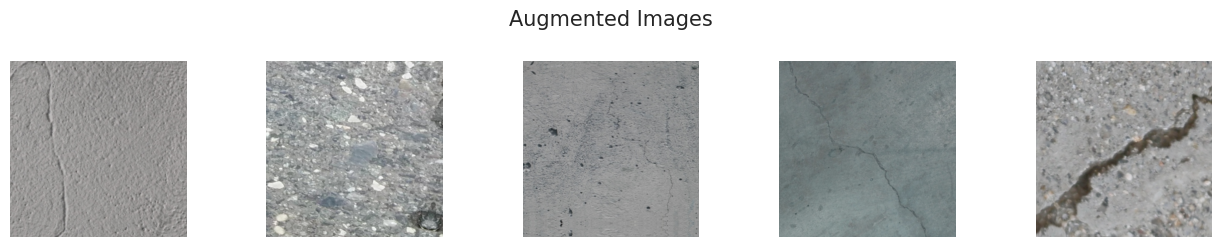

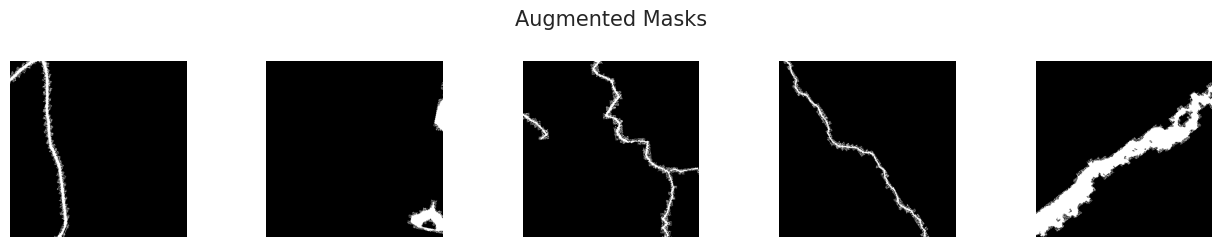

In [148]:
# Augmented train
for i, j in tg:
    break

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Augmented Images', fontsize=15)
axes = axes.flatten()
for img, ax in zip(i[:5], axes[:5]):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(13,2.5))
fig.suptitle('Augmented Masks', fontsize=15)
axes = axes.flatten()
for img, ax in zip(j[:5], axes[:5]):
    ax.imshow(np.squeeze(img, -1), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CrackLSGAN – LSGAN adapted for crack image synthesis  (paper Section 3.2)
# Generator : noise  → 128×128 RGB crack image
# Discriminator: 128×128 RGB → real / fake  (MSE loss, no sigmoid)
# Paper: 4 synthetic images per real sample; FID ≈ 17, IS ≈ 8  (Section 4.3)
# ─────────────────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (Dense, Reshape, Flatten, Dropout,
                                      BatchNormalization, Activation,
                                      Conv2D, Conv2DTranspose,
                                      LeakyReLU, Input)
from tensorflow.keras.models import Sequential, Model

class CrackLSGAN:
    def __init__(self, img_size=128, channels=3, latent_dim=100):
        self.img_size   = img_size
        self.channels   = channels
        self.latent_dim = latent_dim
        self.img_shape  = (img_size, img_size, channels)
        opt = tf.keras.optimizers.Adam(0.0002, 0.5)

        self.discriminator = self._build_discriminator()
        self.discriminator.compile(loss='mse', optimizer=opt, metrics=['accuracy'])

        self.generator = self._build_generator()
        z     = Input(shape=(self.latent_dim,))
        img   = self.generator(z)
        self.discriminator.trainable = False
        self.combined = Model(z, self.discriminator(img))
        self.combined.compile(loss='mse', optimizer=opt)

    def _build_generator(self):
        init = self.img_size // 16  # 8 for img_size=128
        model = Sequential([
            Dense(256 * init * init, input_dim=self.latent_dim),
            Reshape((init, init, 256)),
            Conv2DTranspose(128, 4, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), Activation('relu'),   # → 16
            Conv2DTranspose(64,  4, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), Activation('relu'),   # → 32
            Conv2DTranspose(32,  4, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), Activation('relu'),   # → 64
            Conv2DTranspose(16,  4, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), Activation('relu'),   # → 128
            Conv2D(self.channels, 3, padding='same', activation='tanh'),
        ])
        z = Input(shape=(self.latent_dim,))
        return Model(z, model(z))

    def _build_discriminator(self):
        model = Sequential([
            Conv2D(32,  3, strides=2, padding='same', input_shape=self.img_shape),
            LeakyReLU(0.2), Dropout(0.25),
            Conv2D(64,  3, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), LeakyReLU(0.2), Dropout(0.25),
            Conv2D(128, 3, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), LeakyReLU(0.2), Dropout(0.25),
            Conv2D(256, 3, strides=2, padding='same'),
            BatchNormalization(momentum=0.8), LeakyReLU(0.2), Dropout(0.25),
            Flatten(), Dense(1),   # No sigmoid – LSGAN uses MSE
        ])
        img = Input(shape=self.img_shape)
        return Model(img, model(img))

    def train_on_crack_images(self, image_paths, epochs=2000, batch_size=32, sample_interval=500):
        print(f"Loading up to 500 crack images for LSGAN training...")
        X = []
        for p in image_paths[:500]:
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
            X.append(img)
        X = (np.array(X, dtype=np.float32) - 127.5) / 127.5  # → [-1, 1]
        valid = np.ones((batch_size, 1))
        fake  = np.zeros((batch_size, 1))
        d_losses, g_losses = [], []
        for epoch in range(epochs):
            idx   = np.random.randint(0, len(X), batch_size)
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            gen   = self.generator.predict(noise, verbose=0)
            d_loss = 0.5 * np.add(
                self.discriminator.train_on_batch(X[idx], valid),
                self.discriminator.train_on_batch(gen, fake))
            g_loss = self.combined.train_on_batch(
                np.random.normal(0, 1, (batch_size, self.latent_dim)), valid)
            d_losses.append(d_loss[0]); g_losses.append(g_loss)
            if (epoch + 1) % sample_interval == 0:
                print(f"  [{epoch+1}/{epochs}]  D_loss: {d_loss[0]:.4f}  "
                      f"D_acc: {100*d_loss[1]:.1f}%  G_loss: {g_loss:.4f}")
        return d_losses, g_losses

    def generate_crack_images(self, n, target_size=(448, 448)):
        noise = np.random.normal(0, 1, (n, self.latent_dim))
        imgs  = self.generator.predict(noise, verbose=0)
        imgs  = np.clip((imgs * 0.5 + 0.5) * 255, 0, 255).astype(np.uint8)
        return [cv2.resize(img, target_size) for img in imgs]


In [ ]:
# Train CrackLSGAN and generate 4 synthetic images per real sample
# Paper Section 4.3: FID ≈ 17, IS ≈ 8

crack_gan = CrackLSGAN(img_size=128, channels=3, latent_dim=100)
d_losses, g_losses = crack_gan.train_on_crack_images(
    train_image_files,
    epochs=2000,           # increase for better quality; paper trains until stable
    batch_size=32,
    sample_interval=500
)

# Plot GAN training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(d_losses); axes[0].set_title('Discriminator Loss (LSGAN)'); axes[0].set_xlabel('Epoch')
axes[1].plot(g_losses); axes[1].set_title('Generator Loss (LSGAN)');    axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

# Generate 4 synthetic images per real training sample (paper specification)
n_synthetic = len(train_image_files) * 4
print(f"Generating {n_synthetic} synthetic crack images (4 × {len(train_image_files)} real samples)...")
synthetic_images = crack_gan.generate_crack_images(n_synthetic, target_size=(448, 448))

# Save synthetic images to disk
os.makedirs('/kaggle/working/synthetic_crack_images', exist_ok=True)
synthetic_image_paths = []
for idx, syn in enumerate(synthetic_images):
    path = f'/kaggle/working/synthetic_crack_images/syn_{idx:04d}.jpg'
    cv2.imwrite(path, cv2.cvtColor(syn, cv2.COLOR_RGB2BGR))
    synthetic_image_paths.append(path)

# Pair synthetic images with cycled real masks
synthetic_mask_paths = [train_mask_files[i % len(train_mask_files)]
                        for i in range(len(synthetic_image_paths))]

# Build augmented dataset: real + synthetic
aug_train_images = train_image_files + synthetic_image_paths
aug_train_masks  = train_mask_files  + synthetic_mask_paths
print(f"Augmented dataset: {len(aug_train_images)} images  "
      f"(real: {len(train_image_files)}, synthetic: {len(synthetic_image_paths)})")

# Update training generator to use the augmented dataset
tg = Generator(aug_train_images, aug_train_masks, batch_size, img_dim, augment=True)
train_steps = len(aug_train_images) // batch_size
valid_steps = len(valid_image_files) // batch_size
print(f"tg updated: {train_steps} steps/epoch")

# Visualise a sample of generated images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('LSGAN Generated Crack Images', fontsize=14)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(synthetic_images[i]); ax.axis('off')
plt.tight_layout(); plt.show()


#Model

In [149]:
import numpy as np
from tensorflow.keras.backend import int_shape
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Add, BatchNormalization, Input, Activation, Concatenate
from keras.regularizers import l2

In [150]:
# BatchNormalization and Activation
def BN_Act(x, act = True):
    x = BatchNormalization()(x)
    if act == True:
        x = Activation("relu")(x)
    return x

In [151]:
# conv2d block
def conv2d_block(x, filters, kernel_size = (3, 3), padding = "same", strides = 1):
    conv = BN_Act(x)
    conv = Conv2D(filters, kernel_size, padding = padding, strides = strides)(conv)
    return conv

In [152]:
# Fixed layer
def stem(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    conv = Conv2D(filters, kernel_size, padding = padding, strides = strides)(x)
    conv = conv2d_block(conv, filters, kernel_size = kernel_size, padding = padding, strides = strides)
    
    #skip
    shortcut = Conv2D(filters, kernel_size = (1, 1), padding = padding, strides = strides)(x)
    shortcut = BN_Act(shortcut, act = False) # No activation in skip connection
    
    output = Add()([conv, shortcut])
    return output

In [153]:
#Residual Block
def residual_block(x, filters, kernel_size = (3, 3), padding = "same", strides = 1):
    res = conv2d_block(x, filters, kernel_size = kernel_size, padding = padding, strides = strides)
    res = conv2d_block(res, filters, kernel_size = kernel_size, padding = padding, strides = 1)
    
    shortcut = Conv2D(filters, kernel_size = (1, 1), padding = padding, strides = strides)(x)
    shortcut = BN_Act(shortcut, act = False) # No activation in skip connection
    
    output = Add()([shortcut, res])
    return output

In [154]:
#Upsample concatenation block
def upsample_concat_block(x, xskip):
    u = UpSampling2D((2, 2))(x)
    c = Concatenate()([u, xskip])
    return c

In [155]:
# Complete model Architecture
def ResUNet():
    f = [16, 32, 64, 128, 256]
    inputs = Input((img_dim[0], img_dim[1], 3))
    
    ## Encoder/downsampling/contracting path
    e0 = inputs
    e1 = stem(e0, f[0])
    e2 = residual_block(e1, f[1], strides = 2)
    e3 = residual_block(e2, f[2], strides = 2)
    e4 = residual_block(e3, f[3], strides = 2)
    e5 = residual_block(e4, f[4], strides = 2)
    
    ## Bridge/Bottleneck
    b0 = conv2d_block(e5, f[4], strides = 1)
    b1 = conv2d_block(b0, f[4], strides = 1)
    
    ## Decoder/upsampling/expansive path
    u1 = upsample_concat_block(b1, e4)
    d1 = residual_block(u1, f[4])
    
    u2 = upsample_concat_block(d1, e3)
    d2 = residual_block(u2, f[3])
    
    u3 = upsample_concat_block(d2, e2)
    d3 = residual_block(u3, f[2])
    
    u4 = upsample_concat_block(d3, e1)
    d4 = residual_block(u4, f[1])
    
    outputs = Conv2D(1, (1, 1), padding = "same", activation = "sigmoid")(d4)
    model = Model(inputs, outputs)
    return model

In [156]:
K.clear_session()
model = ResUNet()

In [157]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 448, 448, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 448, 448, 16)         448       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 448, 448, 16)         64        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 448, 448, 16)         0         ['batch_normalization[0][0

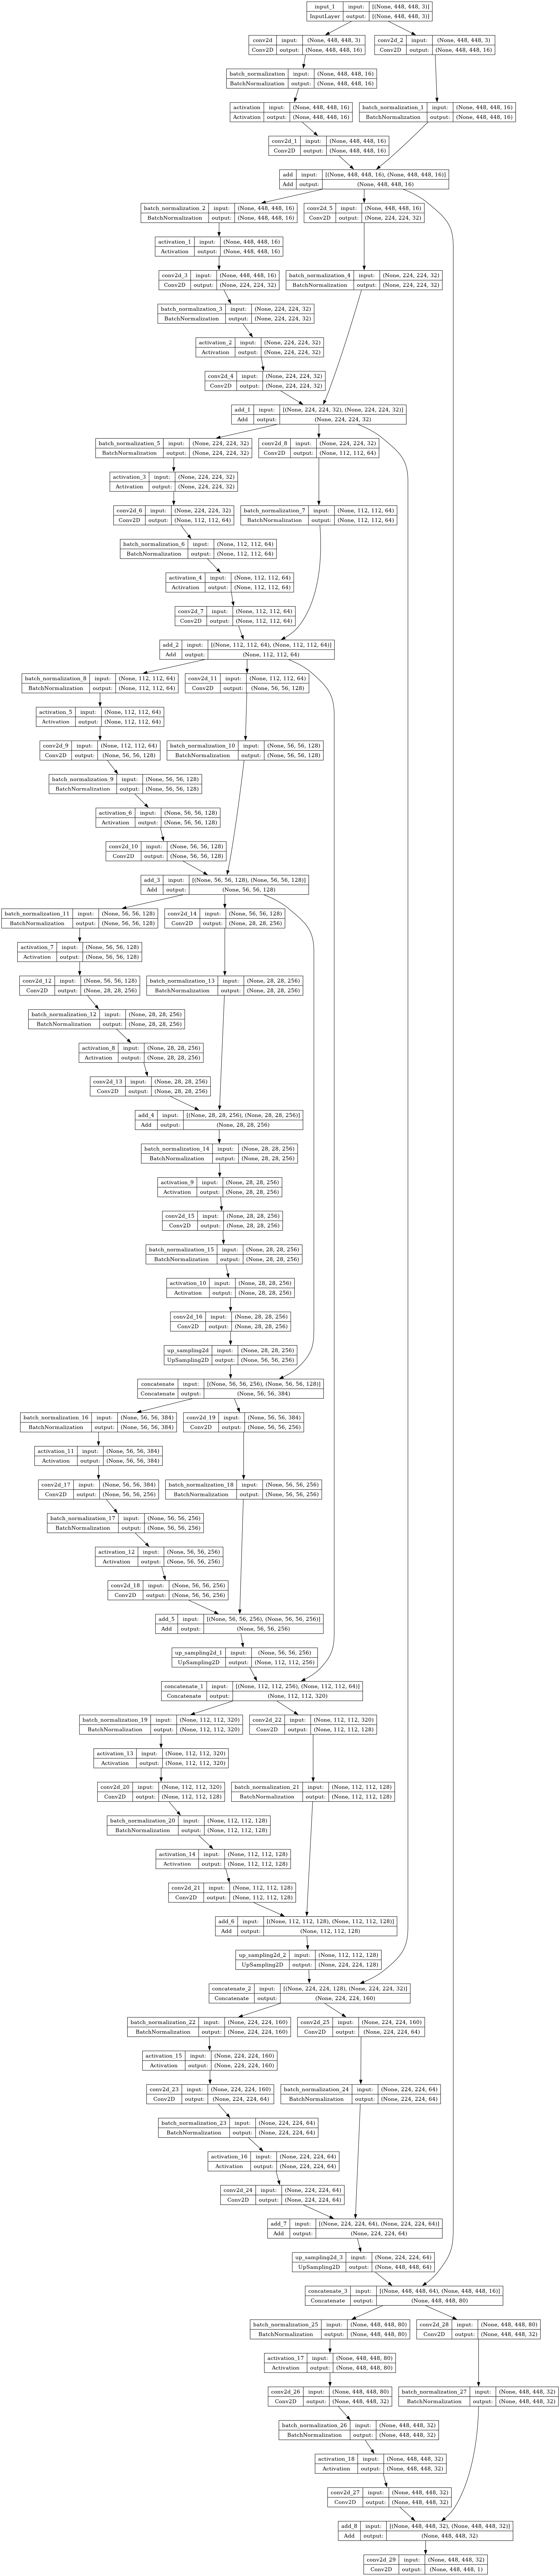

In [158]:
from tensorflow.keras.utils import  plot_model

plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=100,
)

# Loss Function


In [159]:
# ─────────────────────────────────────────────────────────────────────────────
# GOA target function  (Section 3.3.2)
# Trains a fresh ResUNet for a few epochs; returns 1 − Dice so GOA minimises
# what corresponds to maximising the Dice coefficient on the validation set.
# ─────────────────────────────────────────────────────────────────────────────
def target_function(variables_values):
    lr = float(np.clip(variables_values[0], 0.001, 0.1))

    K.clear_session()
    m   = ResUNet()
    opt = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999,
                                    epsilon=1e-07, amsgrad=True)
    m.compile(optimizer=opt, loss=dice_coef_loss, metrics=['accuracy', IOU, dice_coef])

    hist = m.fit(tg, validation_data=vg, epochs=3,
                 steps_per_epoch=train_steps, validation_steps=valid_steps,
                 verbose=0)
    best_val_dice = max(hist.history.get('val_dice_coef', [0.0]))
    del m; K.clear_session()
    return 1.0 - best_val_dice   # GOA minimises → maximise Dice

from pyMetaheuristic.algorithm import grasshopper_optimization_algorithm

smooth = 1.

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_coef_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def IOU(y_true, y_pred):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    thresh = 0.5

    y_true = K.cast(K.greater_equal(y_true, thresh), 'float32')
    y_pred = K.cast(K.greater_equal(y_pred, thresh), 'float32')

    union = K.sum(K.maximum(y_true, y_pred)) + K.epsilon()
    intersection = K.sum(K.minimum(y_true, y_pred)) + K.epsilon()

    iou = intersection/union

    return iou

def bce_dice_loss(y_true, y_pred):

     return binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)
# GOA hyperparameter configuration – paper Table 1
parameters = {
    'grasshoppers': 50,      # N = 50  population size
    'min_values': (0.001,),  # LR lower bound
    'max_values': (0.1,),    # LR upper bound
    'iterations': 50,        # L = 50  termination criterion
    'c_min': 0.4,            # Min Comfort Zone coefficient
    'c_max': 1.0,            # Max Comfort Zone coefficient
    'verbose': True,
    'start_init': None,
    'target_value': None
}

print('Starting GOA optimisation (Table 1): N=50, L=50, LR=[0.001, 0.1]')
goa = grasshopper_optimization_algorithm(target_function=target_function, **parameters)

# Extract best learning rate found by GOA
best_lr_goa = float(goa.iloc[0, 0])
best_dice_goa = 1.0 - float(goa.iloc[0, -1])
print(f'GOA best LR: {best_lr_goa:.6f}   best val Dice: {best_dice_goa:.4f}')

# GOA convergence curve
plt.figure(figsize=(10, 4))
plt.plot(goa.iloc[:, -1].values, marker='o', markersize=4)
plt.title('GOA Convergence – Fitness (1 − Dice) per Iteration')
plt.xlabel('Iteration'); plt.ylabel('Fitness (1 − Dice)')
plt.grid(True); plt.tight_layout(); plt.show()

### Learning Rate Schedular And other callbacks

In [160]:
def lr_schedule(epoch):
    lr =0.001
    if epoch >150:
        lr *=2**-1
    elif epoch >80:
        lr *=2**(-1)
    elif epoch >50:
        lr *=2**(-1)
    elif epoch >30:
        lr *=2**(-1)
    
    print('Learning rate: ', lr)
    return lr

In [161]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import LearningRateScheduler
from keras.optimizers import SGD

In [162]:

import time

start_time = time.time()

# Prepare callbacks for model saving and for learning rate adjustment.
lr_scheduler = LearningRateScheduler(lr_schedule)

lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1),
                               cooldown=0,
                               patience=5,
                               min_lr=0.5e-8)

callbacks = [lr_reducer, lr_scheduler]


### Compiling with adam and beyond

In [163]:
import tensorflow as tf
learning_rate = best_lr_goa if 'best_lr_goa' in dir() else 0.0035
optimiser=tf.keras.optimizers.Adam(
    learning_rate=best_lr_goa if 'best_lr_goa' in dir() else lr_schedule(0),
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
    name="Adam"
)
model.compile(optimizer =optimiser , loss = dice_coef_loss, metrics = ['accuracy', IOU, dice_coef])

Learning rate:  0.001


In [164]:
model.save('/kaggle/working/Adam_and_beyond.h5')

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Training

In [165]:
train_steps = len(train_image_files)//batch_size
valid_steps = len(valid_image_files)//batch_size

history = model.fit(
    tg, 
    steps_per_epoch=train_steps,
    initial_epoch = 0,
    epochs=100,
    validation_data = vg,    
    validation_steps = valid_steps,callbacks=callbacks)

Learning rate:  0.001
Epoch 1/100
27/27 [==============================] - 78s 2s/step - loss: 0.7182 - accuracy: 0.8966 - IOU: 0.1800 - dice_coef: 0.2818 - val_loss: 0.9276 - val_accuracy: 0.1977 - val_IOU: 0.0385 - val_dice_coef: 0.0724 - lr: 0.0010
Learning rate:  0.001
Epoch 2/100
27/27 [==============================] - 60s 2s/step - loss: 0.6694 - accuracy: 0.9512 - IOU: 0.2111 - dice_coef: 0.3306 - val_loss: 0.9308 - val_accuracy: 0.1071 - val_IOU: 0.0361 - val_dice_coef: 0.0692 - lr: 0.0010
Learning rate:  0.001
Epoch 3/100
27/27 [==============================] - 60s 2s/step - loss: 0.6404 - accuracy: 0.9407 - IOU: 0.2305 - dice_coef: 0.3596 - val_loss: 0.9305 - val_accuracy: 0.0715 - val_IOU: 0.0365 - val_dice_coef: 0.0695 - lr: 0.0010
Learning rate:  0.001
Epoch 4/100
27/27 [==============================] - 60s 2s/step - loss: 0.6417 - accuracy: 0.9406 - IOU: 0.2291 - dice_coef: 0.3583 - val_loss: 0.8846 - val_accuracy: 0.9636 - val_IOU: 0.0634 - val_dice_coef: 0.1154 - lr:

In [166]:
history = model.fit(
    tg, 
    steps_per_epoch=train_steps,
    initial_epoch =60,
    epochs=80,
    validation_data = vg,    
    validation_steps = valid_steps,callbacks=callbacks)

Learning rate:  0.0005
Epoch 61/80
27/27 [==============================] - 61s 2s/step - loss: 0.3526 - accuracy: 0.9731 - IOU: 0.4853 - dice_coef: 0.6474 - val_loss: 0.4076 - val_accuracy: 0.9645 - val_IOU: 0.4287 - val_dice_coef: 0.5924 - lr: 5.0000e-04
Learning rate:  0.0005
Epoch 62/80
27/27 [==============================] - 61s 2s/step - loss: 0.3462 - accuracy: 0.9734 - IOU: 0.4909 - dice_coef: 0.6538 - val_loss: 0.3873 - val_accuracy: 0.9702 - val_IOU: 0.4500 - val_dice_coef: 0.6127 - lr: 5.0000e-04
Learning rate:  0.0005
Epoch 63/80
27/27 [==============================] - 61s 2s/step - loss: 0.3537 - accuracy: 0.9730 - IOU: 0.4841 - dice_coef: 0.6463 - val_loss: 0.4084 - val_accuracy: 0.9712 - val_IOU: 0.4299 - val_dice_coef: 0.5916 - lr: 5.0000e-04
Learning rate:  0.0005
Epoch 64/80
27/27 [==============================] - 61s 2s/step - loss: 0.3501 - accuracy: 0.9736 - IOU: 0.4888 - dice_coef: 0.6499 - val_loss: 0.4269 - val_accuracy: 0.9725 - val_IOU: 0.4110 - val_dice_co

In [176]:
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

train_acc = history.history['accuracy']
valid_acc = history.history['val_accuracy']

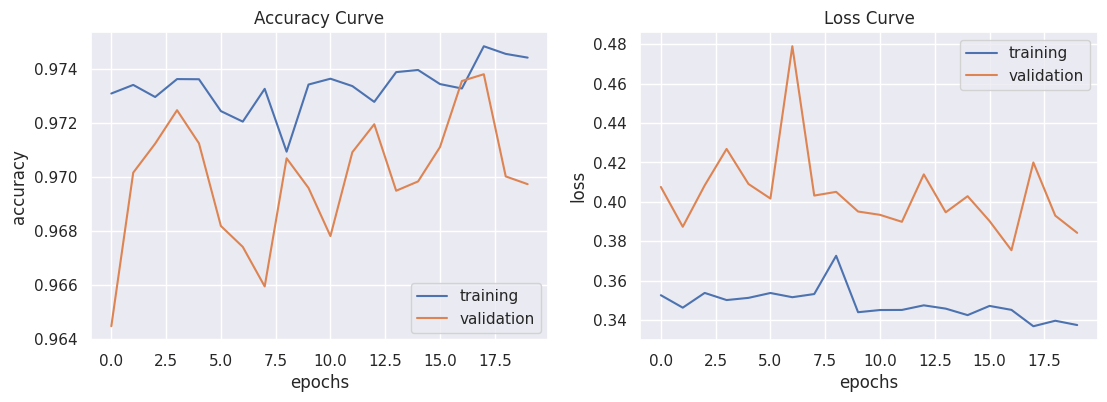

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes = axes.flatten()

axes[0].plot(train_acc, label='training')
axes[0].plot(valid_acc, label='validation')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('accuracy')
axes[0].legend()


axes[1].plot(train_loss, label='training')
axes[1].plot(valid_loss, label='validation')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('loss')
axes[1].legend()

plt.show()

In [169]:
train_dice = history.history['dice_coef']
valid_dice = history.history['val_dice_coef']


train_IOU = history.history['IOU']
valid_IOU = history.history['val_IOU']

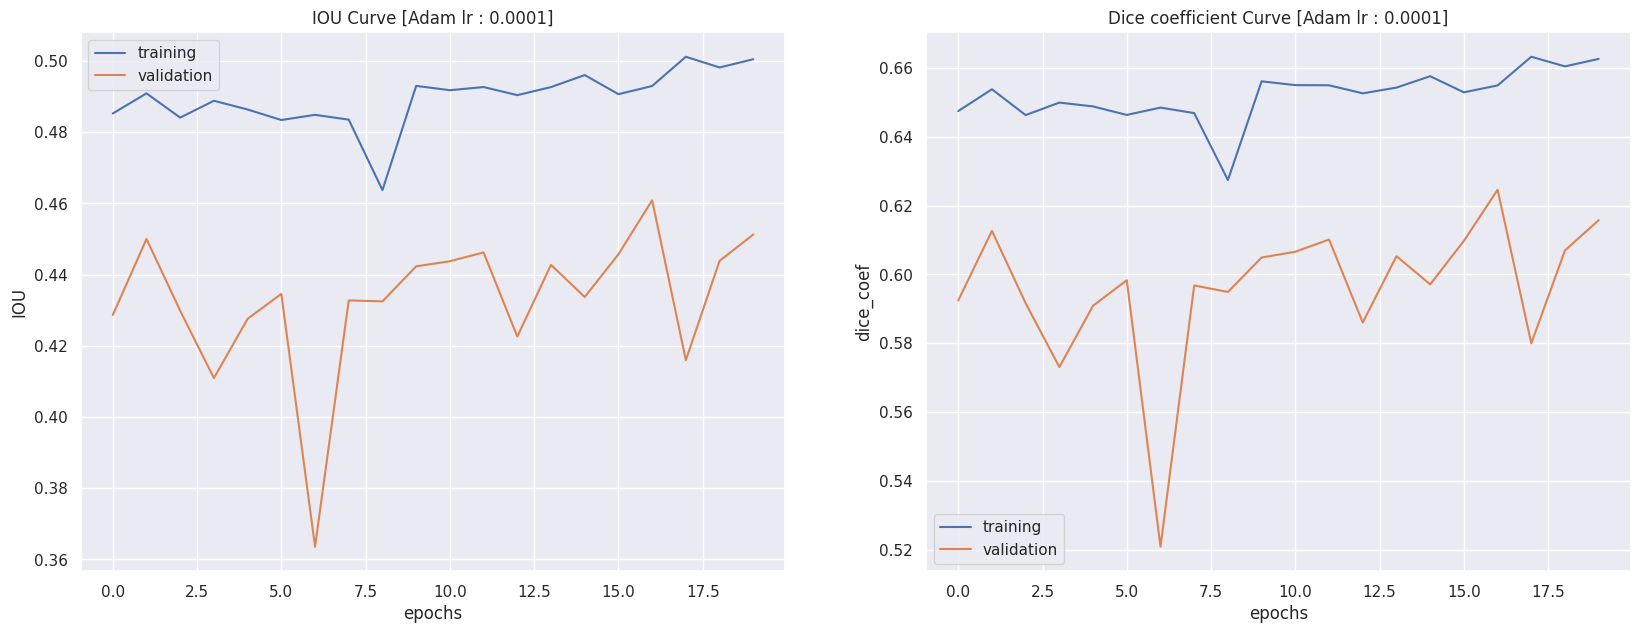

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(20,7))
axes = axes.flatten()

axes[0].plot(train_IOU, label='training')
axes[0].plot(valid_IOU, label='validation')
axes[0].set_title('IOU Curve [Adam lr : 0.0001]')
axes[0].set_xlabel('epochs')
axes[0].set_ylabel('IOU')
axes[0].legend()


axes[1].plot(train_dice, label='training')
axes[1].plot(valid_dice, label='validation')
axes[1].set_title('Dice coefficient Curve [Adam lr : 0.0001]')
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('dice_coef')
axes[1].legend()

plt.show()

## Testing

In [171]:
test_generator = Generator(valid_image_files, valid_mask_files,30 , img_dim)

for x_test, y_test in test_generator:
  break

y_pred = model.predict(x_test)

yy_true = (y_test>0.5).flatten()
yy_pred = (y_pred>0.5).flatten()

/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1284: FutureWarning: RandomContrast has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1258: FutureWarning: This class has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(


1/1 [==============================] - 42s 42s/step


In [172]:
report = classification_report(yy_true, yy_pred, output_dict=True)

Accuracy = accuracy_score(yy_true, yy_pred)

Precision = report['True']['precision']
Recall = report['True']['recall']
F1_score = report['True']['f1-score']

Sensitivity = Recall
Specificity = report['False']['recall']

AUC = roc_auc_score(y_test.flatten(), y_pred.flatten())

IOU = (Precision*Recall)/(Precision+Recall-Precision*Recall)

print("Accuracy: {0:.4f}\n".format(Accuracy))
print("Precision: {0:.4f}\n".format(Precision))
print("Recall: {0:.4f}\n".format(Recall))
print("F1-Score: {0:.4f}\n".format(F1_score))
print("Sensitivity: {0:.4f}\n".format(Sensitivity))
print("Specificity: {0:.4f}\n".format(Specificity))
print("AUC: {0:.4f}\n".format(AUC))
print("IOU: {0:.4f}\n".format(IOU))
print('-'*50,'\n')
print(classification_report(yy_true, yy_pred))

Accuracy: 0.9737

Precision: 0.5561

Recall: 0.7191

F1-Score: 0.6272

Sensitivity: 0.7191

Specificity: 0.9818

AUC: 0.8759

IOU: 0.4569

-------------------------------------------------- 

              precision    recall  f1-score   support

       False       0.99      0.98      0.99   5835839
        True       0.56      0.72      0.63    185281

    accuracy                           0.97   6021120
   macro avg       0.77      0.85      0.81   6021120
weighted avg       0.98      0.97      0.98   6021120



In [173]:
test_generator = Generator(test_image_paths, test_mask_paths,237, img_dim)

for x_test, y_test in test_generator:
  break

y_pred = model.predict(x_test)

yy_true = (y_test>0.5).flatten()
yy_pred = (y_pred>0.5).flatten()

/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1284: FutureWarning: RandomContrast has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/albumentations/augmentations/transforms.py:1258: FutureWarning: This class has been deprecated. Please use RandomBrightnessContrast
  warnings.warn(


8/8 [==============================] - 68s 3s/step


In [174]:
report = classification_report(yy_true, yy_pred, output_dict=True)

Accuracy = accuracy_score(yy_true, yy_pred)

Precision = report['True']['precision']
Recall = report['True']['recall']
F1_score = report['True']['f1-score']

Sensitivity = Recall
Specificity = report['False']['recall']

AUC = roc_auc_score(y_test.flatten(), y_pred.flatten())

IOU = (Precision*Recall)/(Precision+Recall-Precision*Recall)

print("Accuracy: {0:.4f}\n".format(Accuracy))
print("Precision: {0:.4f}\n".format(Precision))
print("Recall: {0:.4f}\n".format(Recall))
print("F1-Score: {0:.4f}\n".format(F1_score))
print("Sensitivity: {0:.4f}\n".format(Sensitivity))
print("Specificity: {0:.4f}\n".format(Specificity))
print("AUC: {0:.4f}\n".format(AUC))
print("IOU: {0:.4f}\n".format(IOU))
print('-'*50,'\n')
print(classification_report(yy_true, yy_pred))

Accuracy: 0.9738

Precision: 0.4940

Recall: 0.5080

F1-Score: 0.5009

Sensitivity: 0.5080

Specificity: 0.9862

AUC: 0.7473

IOU: 0.3341

-------------------------------------------------- 

              precision    recall  f1-score   support

       False       0.99      0.99      0.99  46336383
        True       0.49      0.51      0.50   1230465

    accuracy                           0.97  47566848
   macro avg       0.74      0.75      0.74  47566848
weighted avg       0.97      0.97      0.97  47566848



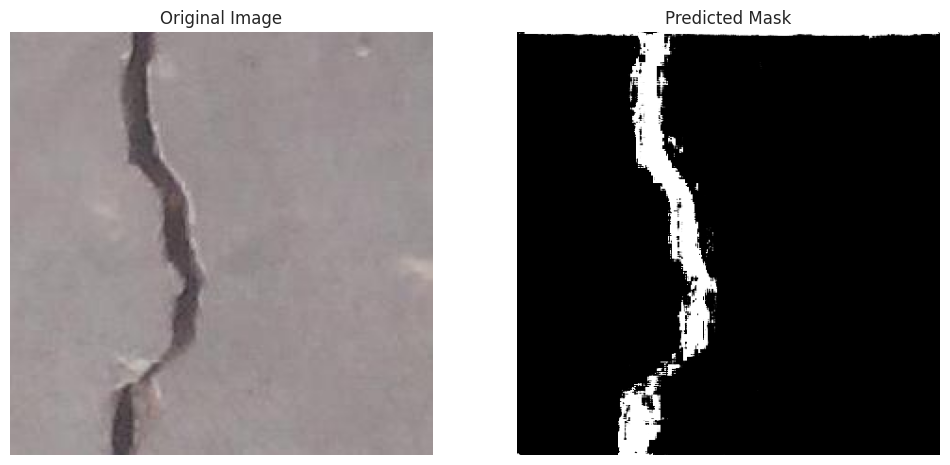

1/1 [==============================] - 1s 533ms/step


In [195]:
import cv2
import numpy as np
from keras.models import load_model
import matplotlib.pyplot as plt

def predict_mask(model_path, input_image_path):
    # Load the trained model
    model = load_model(model_path, custom_objects={'dice_coef_loss': dice_coef_loss, 'IOU': IOU, 'dice_coef': dice_coef})

    # Load and preprocess the input image
    input_image = cv2.imread(input_image_path)
    input_image = cv2.resize(input_image, (448, 448))  # Resize the input image to match the model's input shape
    input_image = input_image / 255.0  # Normalize pixel values

    # Perform prediction
    mask = model.predict(np.array([input_image]))

    # Threshold the mask (optional, depending on your model output)
    threshold = 0.5  # Adjust as needed
    mask[mask >= threshold] = 1
    mask[mask < threshold] = 0

    return input_image, mask[0]

from IPython.display import display, Image

# Read the image file
image_path = '/kaggle/input/image111/output.png'

# Display the image
display(Image(filename=image_path))



# Example usage:
image_path = "/kaggle/input/image111/output.png"
#print_image(image_path)


# Example usage
model_path = '/kaggle/working/Adam_and_beyond.h5'
input_image_path = '/kaggle/input/image1/00016.jpg'

input_image, predicted_mask = predict_mask(model_path, input_image_path)
#plot_mask(input_image, predicted_mask)


## Connected Component Analysis (CCA)
Extracts **width** (w_k), **height** (h_k) and **aspect ratio** (AR_k = w_k / h_k) from each predicted binary crack mask. (Paper Section 3.4, Algorithm 2)


In [ ]:
from skimage import measure

def connected_component_analysis(binary_mask, min_area=50):
    """
    CCA for crack geometry extraction (Algorithm 2 in paper).
    Returns list of dicts: bbox, width, height, aspect_ratio, area, centroid.
    """
    labeled = measure.label(binary_mask, connectivity=2)
    results  = []
    for region in measure.regionprops(labeled):
        if region.area < min_area:
            continue
        y_min, x_min, y_max, x_max = region.bbox
        w_k  = x_max - x_min + 1          # Eq. Algorithm 2: wk
        h_k  = y_max - y_min + 1          # Eq. Algorithm 2: hk
        ar_k = w_k / h_k if h_k > 0 else 0  # ARk = wk / hk
        results.append({
            'label':        region.label,
            'bbox':         (x_min, y_min, x_max, y_max),
            'width':        w_k,
            'height':       h_k,
            'aspect_ratio': ar_k,
            'area':         region.area,
            'centroid':     region.centroid,
        })
    return results


In [ ]:
# Apply CCA to test-set predictions  (x_test / y_pred from the Testing section above)
all_widths, all_heights, all_ars = [], [], []

for i in range(min(5, len(x_test))):
    img         = x_test[i]
    binary_mask = (y_pred[i, :, :, 0] > 0.5).astype(np.uint8)
    components  = connected_component_analysis(binary_mask)
    all_widths.extend( [c['width']        for c in components])
    all_heights.extend([c['height']       for c in components])
    all_ars.extend(    [c['aspect_ratio'] for c in components])

    print(f'Image {i+1}: {len(components)} crack component(s)')
    for j, comp in enumerate(components[:3]):
        print(f'  Comp {j+1}: wk={comp["width"]}px  hk={comp["height"]}px  '
              f'AR={comp["aspect_ratio"]:.3f}  area={comp["area"]}px²')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'CCA – Sample {i+1}', fontsize=13)
    axes[0].imshow(img);                      axes[0].set_title('Input');          axes[0].axis('off')
    axes[1].imshow(binary_mask, cmap='gray'); axes[1].set_title('Predicted Mask'); axes[1].axis('off')
    axes[2].imshow(img)
    for comp in components:
        x0, y0, x1, y1 = comp['bbox']
        rect = plt.Rectangle((x0, y0), x1-x0, y1-y0,
                              fill=False, edgecolor='red', linewidth=2)
        axes[2].add_patch(rect)
        cy = (y0+y1)//2; cx = (x0+x1)//2
        axes[2].annotate('', xy=(x1, cy), xytext=(x0, cy),
                          arrowprops=dict(arrowstyle='<->', color='cyan', lw=2))
        axes[2].annotate('', xy=(cx, y1), xytext=(cx, y0),
                          arrowprops=dict(arrowstyle='<->', color='lime', lw=2))
        axes[2].text(x0, y0-4,
                     f'w={comp["width"]}px h={comp["height"]}px AR={comp["aspect_ratio"]:.2f}',
                     color='yellow', fontsize=7, backgroundcolor='black')
    axes[2].set_title('CCA: Width (cyan) & Height (lime)'); axes[2].axis('off')
    plt.tight_layout(); plt.show()


In [ ]:
# Crack geometry distribution across all detected components
if all_widths:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Crack Geometry Distribution (CCA)', fontsize=14)
    axes[0].hist(all_widths,  bins=20, color='steelblue', edgecolor='k')
    axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Width (px)')
    axes[1].hist(all_heights, bins=20, color='seagreen',  edgecolor='k')
    axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Height (px)')
    axes[2].hist(all_ars,     bins=20, color='tomato',    edgecolor='k')
    axes[2].set_title('Aspect Ratio (w/h)');  axes[2].set_xlabel('AR')
    plt.tight_layout(); plt.show()

    print(f'Width  – min {min(all_widths):3d}  max {max(all_widths):4d}  mean {np.mean(all_widths):.1f} px')
    print(f'Height – min {min(all_heights):3d}  max {max(all_heights):4d}  mean {np.mean(all_heights):.1f} px')
    print(f'AR     – min {min(all_ars):.3f}  max {max(all_ars):.3f}  mean {np.mean(all_ars):.3f}')
    print('Paper example (Fig. 27): hk = 276 px, wk = 4 px  (narrow vertical crack)')


## Model Comparison  (Table 6 from paper)
| Model | Precision | Recall | F1 | IoU | Dice |
|---|---|---|---|---|---|
| FCN | 0.6830 | 0.7206 | 0.7013 | 0.5400 | 0.5200 |
| SegNet | 0.6893 | 0.7303 | 0.7092 | 0.5494 | 0.5312 |
| UNet | 0.6852 | 0.7541 | 0.7180 | 0.5600 | 0.5220 |
| TransUNet | 0.7025 | 0.7424 | 0.7219 | 0.5648 | 0.6109 |
| RUC-UNet | 0.6988 | 0.7619 | 0.7290 | 0.5736 | 0.6433 |
| Nested UNet | 0.7611 | 0.6212 | 0.6614 | 0.5211 | 0.6614 |
| Att-UNet | 0.6751 | 0.6344 | 0.6299 | 0.5044 | 0.6299 |
| AN-UNet | 0.7810 | 0.6129 | 0.6656 | 0.5433 | 0.6656 |
| **GOA-UNet (ours)** | **0.9214** | **0.7739** | **0.8412** | **0.7292** | **0.7122** |


In [ ]:
import pandas as pd

comparison = {
    'Model':     ['FCN','SegNet','UNet','TransUNet','RUC-UNet','Nested UNet','Att-UNet','AN-UNet','GOA-UNet'],
    'Precision': [0.6830,0.6893,0.6852,0.7025,0.6988,0.7611,0.6751,0.7810,0.9214],
    'Recall':    [0.7206,0.7303,0.7541,0.7424,0.7619,0.6212,0.6344,0.6129,0.7739],
    'F1 Score':  [0.7013,0.7092,0.7180,0.7219,0.7290,0.6614,0.6299,0.6656,0.8412],
    'IoU':       [0.5400,0.5494,0.5600,0.5648,0.5736,0.5211,0.5044,0.5433,0.7292],
    'Dice':      [0.5200,0.5312,0.5220,0.6109,0.6433,0.6614,0.6299,0.6656,0.7122],
}
df = pd.DataFrame(comparison)
print(df.to_string(index=False))

colors = ['#1f77b4'] * (len(df) - 1) + ['#d62728']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Comparison – Crack Detection (Table 6)', fontsize=14)

x = np.arange(len(df)); w = 0.16
for k, (metric, col) in enumerate(zip(
        ['Precision','Recall','F1 Score','IoU','Dice'],
        ['royalblue','seagreen','tomato','purple','orange'])):
    axes[0].bar(x + (k-2)*w, df[metric], w, label=metric, color=col, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('Score'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_title('All Metrics')

axes[1].barh(df['Model'], df['F1 Score'], color=colors, edgecolor='k', alpha=0.85)
axes[1].axvline(df['F1 Score'].iloc[-1], color='red', ls='--', lw=2,
                 label=f"GOA-UNet F1 = {df['F1 Score'].iloc[-1]:.4f}")
axes[1].set_xlabel('F1 Score'); axes[1].legend(); axes[1].grid(axis='x', alpha=0.3)
axes[1].set_title('F1-Score Comparison')
plt.tight_layout(); plt.show()
